# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках) и пришлите `.ipynb` **с выполненными ячейками** и его PDF-экспорт (`File → Save and Export Notebook As → PDF` или `HTML → печать в PDF`). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это неочевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

#### **(а)**

**Ответ:** 

$\displaystyle\min_{x} f(x)=\displaystyle\min_{x}((x_{1}-1)^{2}+(x_{2}-2)^{2}+(x_{3}-3)^{2}) \quad\text{при}\quad g(x) = (x_{1}+x_{2}+x_{3}-1,x_{1}-x_{3}) = 0, \; h$ нет

| | |
|---|---|
| $x$ | $x=(x_{1},x_{2},x_{3}) \in \mathbb{R}^3$, координаты трёхмерного пространства|
| Класс | QP |
| Наличие ограничений | С ограничениями-равенствами |
| Выпуклость | Выпуклая |
| Решение | $(\frac{1}{3}, \frac{1}{3}, \frac{1}{3})$ |

**Пояснение выпуклости**

Раскрывая $f(x)=(x_{1}-1)^{2}+(x_{2}-2)^{2}+(x_{3}-3)^{2}$, получаем: $f(x)=x_{1}^{2}+x_{2}^{2}+x_{3}^{2}-2x_{1}-4x_{2}-6x_{3}+14$.

Стандартная форма квадратичного программирования (QP): $f(x) = \frac{1}{2} x^{T}Qx+c^{T}x$.

В нашем случае $Q = \begin{pmatrix} 2 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 2 \end{pmatrix}, с = \begin{pmatrix} -2 \\ -4 \\ -6 \end{pmatrix}$. Очевидно, что все собственные значения $Q > 0 \Rightarrow Q \succ 0$ и задача выпукла.

In [2]:
Q = np.array([[2.0, 0.0, 0.0], [0.0, 2.0, 0.0], [0.0, 0.0, 2.0]])
c = np.array([-2.0, -4.0, -6.0])

def f1(x):
    return 0.5 * x @ Q @ x + c @ x

def g1(x):
    return np.array([
        x[0] + x[1] + x[2] - 1,
        x[0] - x[2]
    ])

x0_1 = np.array([0.0, 0.0, 0.0])

constraints = [{'type': 'eq', 'fun': g1}]

res = minimize(
    f1, x0_1,
    method='SLSQP',
    constraints=constraints,
)

print("minimize:", res.x.round(6))
print("g(x) =", g1(res.x))
print("f(x) =", res.fun)

minimize: [0.333333 0.333333 0.333333]
g(x) = [ 0.00000000e+00 -5.55111512e-17]
f(x) = -3.6666666666666665


#### **(б)**

**Ответ:** 

$\displaystyle\min_{x} f(x) = \displaystyle\min_{x}c^{T}x \quad\text{при}\quad h(x) = (x, Ax-b) \ge 0, \; g$ нет

| | |
|---|---|
| $x$ | $x \in \mathbb{R}^n$, количество единиц продуктов|
| Класс | LP |
| Наличие ограничений | С ограничениями-неравенствами |
| Выпуклость | Выпуклая (все LP выпуклые) |

#### **(в)**

**Ответ:**

$\displaystyle\min_{x} f(x)=\displaystyle\min_{x}(-x_{1}x_{2}) \quad\text{при}\quad g(x) = (x_{1}^2+x_{2}^2-1) = 0,\;  h(x) = \begin{pmatrix} x_{1} \\ x_{2} \end{pmatrix} \ge 0$

| | |
|---|---|
| $x$ | $x \in \mathbb{R}^2$, вершина прямоугольника в первой четверти окружности|
| Класс | QCQP, целевая функция и ограничения являются квадратичными |
| Наличие ограничений | С ограничениями |
| Выпуклость | Невыпуклая, поскольку $g(x)$ не является линейной|

**Пояснение**

Исходя из условий задачи есть несколько способов построения прямоугольника.  

В своём решении прямоугольник будет задавать одной точкой: $(x_{1}^{*}, x_{2}^{*})$ (рис.3.1).  
Поскольку стороны прямоугольника параллельны осям, то существует единственный способ его построения (рис.3.2).  
Стороны такого прямоугольника равны $2x_{1}^{*}$ и $2x_{2}^{*}$, а площадь $S = 4x_{1}^{*}x_{2}^{*}$ (коэффициент можно упустить).  

Стоит отметить, что при $x_{1} = 0$ или $x_{2} = 0$ (рис.3.3) прямоугольник вырождается и площадь становится равной нулю (соответственно $f(x) = 0$). Поскольку мы минимизируем $f(x)$, а во внутренних точках допустимого множества $f(x) < 0$, граничные точки заведомо не являются оптимальными и использование нестрогих неравенств не влияет на точку минимума.


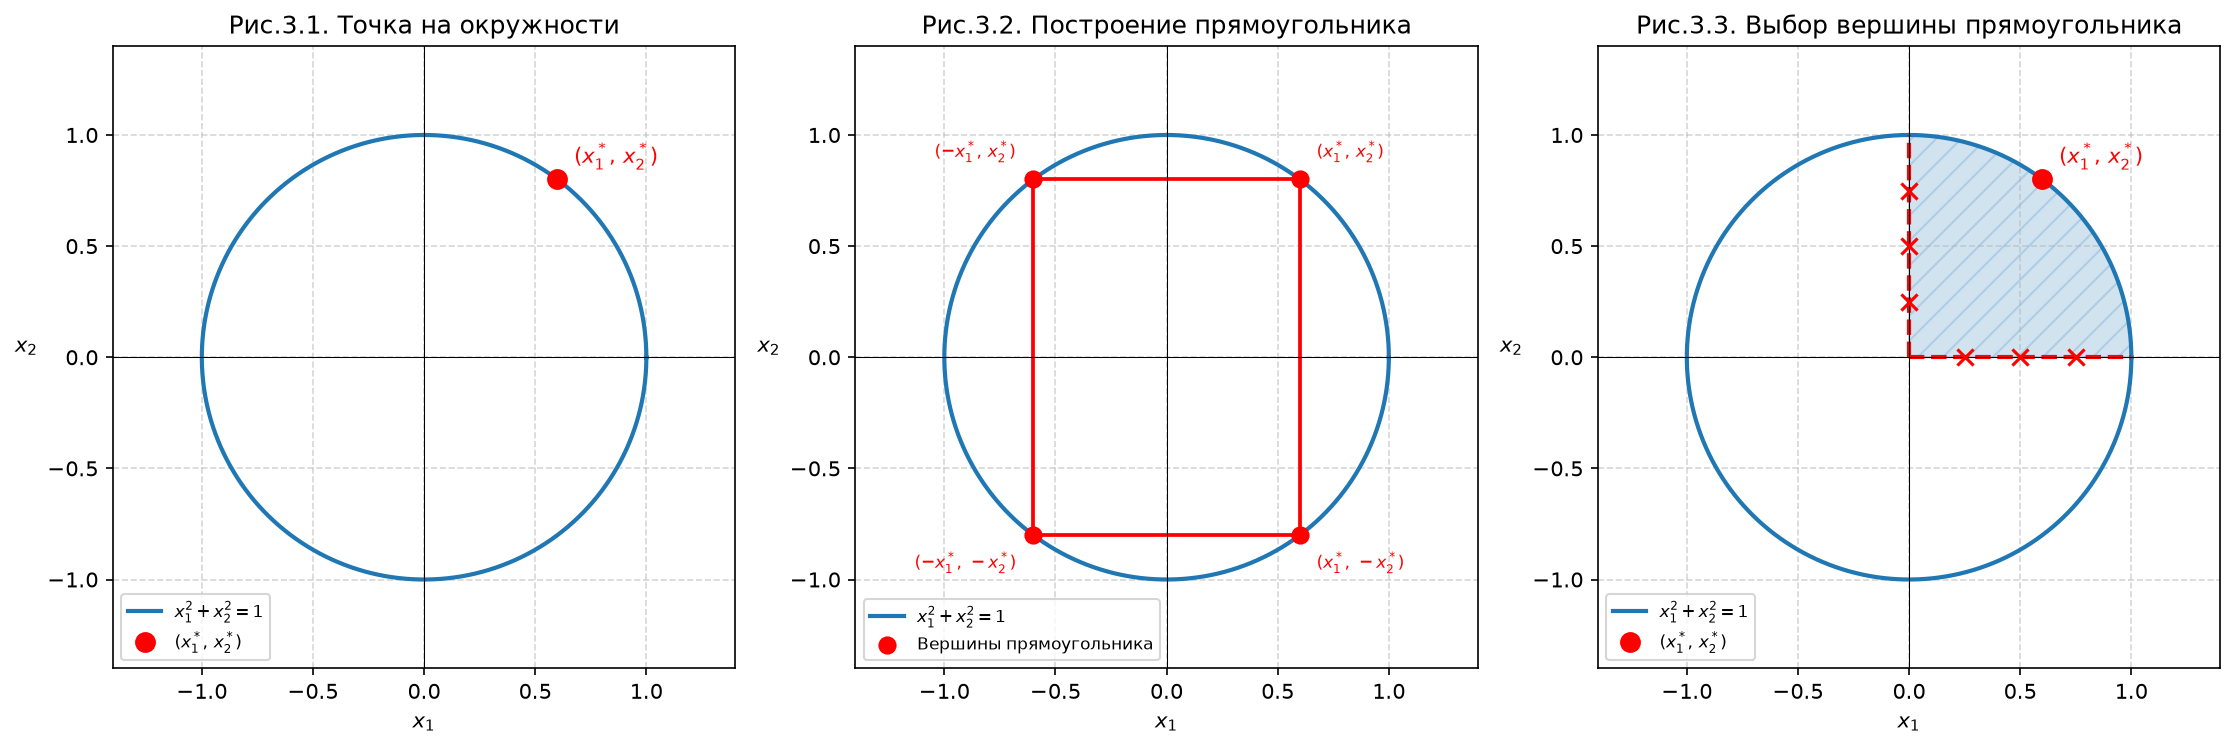

In [2]:
from IPython.display import Image, display
display(Image(filename='hw01_task13.png', embed=True))


#### **(г)**

**Ответ:** 

$\displaystyle\min_{x} f(x) = \displaystyle\min_{x} (\frac{1}{2} \sum_{i=1}^{N} (\varphi(t_{i}, x) - y_{i})^2) = \displaystyle\min_{x} (\frac{1}{2} \sum_{i=1}^{N} (x_1 \sin(x_2 t_{i} + x_3) - y_{i})^2), \; g$ и $h$ нет

| | |
|---|---|
| $x$ | $x \in \mathbb{R}^3$, вектор, определяющий амплитуду, частоту и фазовый сдвиг |
| Класс | NLP |
| Наличие ограничений | Без ограничений |
| Выпуклость | Невыпуклая |

**Пояснение**

Задача не является выпуклой поскольку в целевой функции есть тригонометрическая функция (синус). 

Рассмотрим ситуацию, когда глобальный минимум находится в точке $({x_{1}, x_{2}, x_{3}})$,  
тогда гарантированно существует множество глобальных минимумов для точек $((-1)^i x_{1}, x_{2}, x_{3} + \pi i)$, где $i \in \mathbb{Z}$.

Объясняется это свойством синуса: $\sin(\alpha+\pi)=-\sin(\alpha)$.

#### **(д, бонус)**

**Ответ:**

Введём вспомогательную переменную $s \ge |a_{i}^{T}x-b_{i}|$. Пусть $t = \begin{pmatrix} x \\ s \end{pmatrix} = \begin{pmatrix} x_{1} \\ x_{2} \\ \vdots \\ x_{n} \\ s \end{pmatrix} \in \mathbb{R}^{n+1} $.  

$\displaystyle\min_{t} s \quad\text{при}\quad h(t) = \begin{pmatrix} s - a_{1}^{T}x+b_{1} \\ s + a_{1}^{T}x-b_{1} \\ s - a_{2}^{T}x+b_{2} \\ s + a_{2}^{T}x-b_{2} \\ \vdots \\ s - a_{N}^{T}x+b_{N} \\ s + a_{N}^{T}x-b_{N} \end{pmatrix} \ge 0$ $g$ нет

| | |
|---|---|
| $t$ | $t \in \mathbb{R}^{n+1}$, вектор, содержащий исходные точки из пространства $\mathbb{R}^{n}$ и дополнительную переменную |
| Класс | LP |
| Наличие ограничений | С ограничениями-неравенствами |
| Выпуклость | Выпуклая (все LP выпуклые) |

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

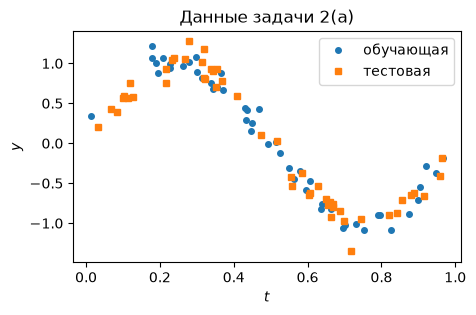

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

In [4]:
mse_train = []
mse_test = []
ds = range(1, 16)

In [5]:
for d in ds:
    A_train = np.vander(t_train, d + 1, increasing=True)
    A_test = np.vander(t_test, d + 1, increasing=True)

    x_opt = np.linalg.lstsq(A_train, y_train, rcond=None)[0]

    y_pred_train = A_train @ x_opt
    y_pred_test = A_test @ x_opt

    mse_train_vals = np.mean((y_train - y_pred_train)**2)
    mse_test_vals = np.mean((y_test - y_pred_test)**2)

    mse_train.append(mse_train_vals)
    mse_test.append(mse_test_vals)

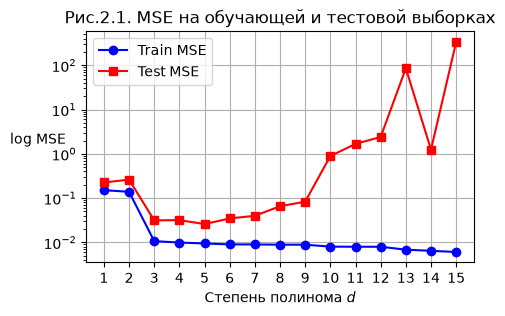

In [6]:
plt.figure(figsize=(5, 3))
plt.plot(ds, mse_train, 'o-', label='Train MSE', color='blue')
plt.plot(ds, mse_test, 's-', label='Test MSE', color='red')

plt.yscale('log')

plt.xlabel('Степень полинома $d$')
plt.ylabel('log MSE', rotation=0)
plt.title('Рис.2.1. MSE на обучающей и тестовой выборках')
plt.xticks(ds)
plt.legend()
plt.grid(True)
plt.show()

**Ответ:** 

На рис.2.1 можно наблюдать уменьшение среднеквадратичных ошибок на тренировочной и тестовой выборках.  
Резкое падение ошибки для полинома **3-й степени** объясняется тем, что линейные и квадратичные функции не могут описывать кривую с двумя изгибами.  

После полинома **9-й степени** наблюдается различное поведение кривых - ошибка на тренировочных данных продолжила уменьшаться, а на тестовых резко возросла.  
Такое поведение характеризуется наличием шума в исходных данных, под которые модель начинает сильно подстраиваться (переобучение, теряется свойство обобщённости).  
Также можно заметить, что обучающая выборка имеет значительный пропуск в начале рассматриваемого диапазона. Это также влияет на среднеквадратическую ошибку.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [7]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [8]:
A_ub = -A
b_ub = -b

is_active = lambda r, tol=1e-9: np.abs(r) < tol
check_active = lambda v, tol=1e-9: np.where(is_active(v), "Активно", "Неактивно")

**Первый случай**

In [9]:
res1 = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(0, None))

residual_A_1 = A @ res1.x - b
print("Ax>=b:", check_active(residual_A_1))
print("x>=0:", check_active(res1.x))
print("Оптимальный x:", res1.x)
print("Стоимость:", res1.fun)

Ax>=b: ['Активно' 'Активно' 'Активно']
x>=0: ['Неактивно' 'Неактивно' 'Активно' 'Активно']
Оптимальный x: [ 2.  4. -0.  0.]
Стоимость: 16.0


**Второй случай**

In [10]:
b_2 = np.copy(b)
b_2[0] += 1
b_ub2 = -b_2

In [11]:
res2 = linprog(c, A_ub=A_ub, b_ub=b_ub2, bounds=(0, None))

residual_A_2 = A @ res2.x - b_2
print("Ax>=b:", check_active(residual_A_2))
print("x>=0:", check_active(res2.x))
print("Оптимальный x:", res2.x)
print("Стоимость:", res2.fun)

Ax>=b: ['Активно' 'Активно' 'Активно']
x>=0: ['Неактивно' 'Неактивно' 'Активно' 'Неактивно']
Оптимальный x: [1.88888889 3.55555556 0.         0.66666667]
Стоимость: 17.11111111111111


**Ответ:**

В обоих случаях ограничение Ax>=b всегда активно, составленная диета обеспечивает ровно требуемое количество веществ. 

В первом случае решение вышло дешевле, чем второе.

Во втором решении используется три различных вида товаров, в первом - только два.

Особенностью первого решения является целочисленность ответа, применимая в реальной жизни (в реальном мире нельзя купить 1,(8) бутылок молока). 

